# Méthode FOB — la méthode retenue

Ce notebook montre, PAS À PAS, comment on obtient le réseau cyclable FOB : des tags OpenStreetMap
bruts à la longueur effective par commune, en passant par les modèles LightGBM déjà entraînés (voir
`artefacts.py` - ce dépôt ne peut pas les réentraîner, il manque les exports GéoVélo bruts ; la méthode
d'entraînement elle-même est documentée en section 0.1, voir `entrainement.py`).

**C'est CETTE méthode que les étapes suivantes du projet doivent utiliser** (voir `../README.md` pour
le comparatif avec les deux autres méthodes essayées).

Deux passes bien séparées : une passe A LÉGÈRE sur TOUS les tronçons (tags -> matrice de variables ->
probabilité d'inclusion, voir `osm_extraction.py`/`caracteristiques.py`/`application_modele.py`), puis
une passe B COÛTEUSE (géométrie, voir `osm_extraction.py`) réservée aux seuls tronçons que la passe A a
retenus - deux ordres de grandeur plus petits. C'est ce qui rend FOB praticable sur un poste de travail
malgré les ~12 millions de tronçons `highway=*` de la France entière.

## 0. Tableau de bord — méthode et qualité des modèles vendorisés

Cette section documente COMMENT les modèles FOB ont été entraînés (méthode, voir
[`entrainement.py`](entrainement.py)) et resitue leurs vraies métriques de validation - calculées une
fois, à l'entraînement, et vendorisées dans `models/fob/meta.json`. Ce notebook ne réentraîne jamais
rien : il charge et vérifie les modèles déjà là (voir [`artefacts.py`](artefacts.py)).

In [1]:
import sys
from pathlib import Path

ICI = Path.cwd()
sys.path.insert(0, str(ICI))
RACINE = ICI.parents[2]

import pandas as pd
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 20)

DOSSIER_MODELES_FOB = RACINE / "models" / "fob"
FICHIER_COMMUNES = RACINE / "data" / "donnees_valides" / "zones" / "communes.parquet"
DOSSIER_SORTIE = RACINE / "data" / "donnees_valides" / "reseau_fob"
ANNEE = 2024

from artefacts import verifier_modeles

meta_modeles = verifier_modeles(DOSSIER_MODELES_FOB)
print(f"modèles vendorisés chargés depuis {DOSSIER_MODELES_FOB}")
print(f"snapshot d'entraînement : {meta_modeles['tag']}")
print(f"{meta_modeles['n_ways']:,} tronçons vus, {meta_modeles['n_pos']:,} appariés à GéoVélo ({meta_modeles['n_labels_gv']:,} labels GéoVélo au total)")
print(f"durée d'entraînement (réelle, vendorisée) : {meta_modeles['train_seconds'] / 60:.0f} min")

modèles vendorisés chargés depuis C:\Users\olivi\Documents\GitHub\LEVEL-Cyclist-Risk-Estimation\VV6\models\fob
snapshot d'entraînement : output\osm\260701
12,171,115 tronçons vus, 385,116 appariés à GéoVélo (385,159 labels GéoVélo au total)
durée d'entraînement (réelle, vendorisée) : 33 min


### 0.1 Méthode d'entraînement — [`entrainement.py`](entrainement.py)

Port fidèle du code qui a produit les modèles vendorisés (non exécutable ici : il faut les exports
GéoVélo bruts, source tierce volumineuse non fournie - voir le docstring du module et
`../README.md`/`artefacts.py`). Deux étages :

1. **Inclusion** (`entrainer_inclusion`) : LightGBM binaire sur TOUS les tronçons `highway=*`, négatifs
   sous-échantillonnés à 25 % et repondérés (`NEGATIVE_SAMPLE_FRACTION`), seuil de décision qui
   maximise le F1 sur la validation (pas 0.5 fixe).
2. **Attributs** (`entrainer_attributs`) : un LightGBM multiclasse par attribut GéoVélo (10 cibles,
   voir `etiquettes.CIBLES`), entraîné sur les seuls tronçons présents dans GéoVélo. `ame_d`/`ame_g`
   sont réglés sur une petite grille d'hyperparamètres (`GRILLE_HYPERPARAMETRES`) ; les 8 autres cibles
   réutilisent directement les paramètres gagnants de `ame_d`.

Découpage entraînement/validation/test : déterministe, par hachage de l'id OSM (`pli_de`) - un même
tronçon tombe toujours dans le même pli, quel que soit le snapshot. Pli 0 = test (jamais vu pendant le
réglage), pli 1 = validation (arrêt anticipé), plis 2-4 = entraînement.

In [2]:
import entrainement as E

hyperparams = pd.DataFrame(
    [
        {"étage": "inclusion", "cible": "inclusion", **meta_modeles["inclusion"]["params"], "itérations": meta_modeles["inclusion"]["best_iteration"]},
        {"étage": "attributs (réglé)", "cible": "ame_d", **meta_modeles["targets"]["ame_d"]["params"], "itérations": meta_modeles["targets"]["ame_d"]["best_iteration"]},
        {"étage": "attributs (paramètres partagés)", "cible": "sens_d", **meta_modeles["targets"]["sens_d"]["params"], "itérations": meta_modeles["targets"]["sens_d"]["best_iteration"]},
    ]
).fillna("(valeur de base)")
print(f"grille explorée pour les cibles réglées ({len(E.CIBLES_AMENAGEMENT)} cibles) : {len(E.GRILLE_HYPERPARAMETRES)} jeux d'hyperparamètres, {E.N_PLIS} plis (déterministes par hachage d'id OSM)")
hyperparams

grille explorée pour les cibles réglées (2 cibles) : 5 jeux d'hyperparamètres, 5 plis (déterministes par hachage d'id OSM)


,étage,cible,num_leaves,min_data_in_leaf,feature_fraction,itérations,lambda_l2
0,inclusion,inclusion,63,20,0.8,380,(valeur de base)
1,attributs (réglé),ame_d,63,50,0.6,494,5.0
2,attributs (paramètres partagés),sens_d,63,50,0.6,390,5.0


### 0.2 Qualité du modèle d'inclusion

Métriques calculées sur le pli 0 (test, jamais vu pendant le réglage) - voir `meta_modeles["inclusion"]`.

In [3]:
incl = meta_modeles["inclusion"]
qualite_inclusion = pd.DataFrame(
    {
        "précision": [incl["precision"]],
        "rappel": [incl["recall"]],
        "F1": [incl["f1"]],
        "AUC": [incl["auc"]],
        "précision moyenne (AP)": [incl["ap"]],
        "seuil retenu": [incl["threshold"]],
        "vrais positifs": [incl["tp"]],
        "faux positifs": [incl["fp"]],
        "faux négatifs": [incl["fn"]],
        "tronçons test": [incl["n_holdout"]],
    },
    index=["inclusion"],
).round(4)
qualite_inclusion

,précision,rappel,F1,AUC,précision moyenne (AP),seuil retenu,vrais positifs,faux positifs,faux négatifs,tronçons test
inclusion,0.9912,0.9982,0.9947,0.9999,0.9973,0.5471,76441,676,135,2432603


### 0.3 Qualité des modèles d'attribut

Pour chaque cible, l'accuracy du modèle contre deux lignes de base : `baseline_majoritaire` (toujours
prédire la classe la plus fréquente) et `baseline_lookup` (prédire à partir d'un dictionnaire
tags -> classe majoritaire, sans apprentissage) - le modèle doit dépasser nettement les deux pour
justifier le coût d'un LightGBM plutôt qu'une règle simple.

In [4]:
qualite_attributs = pd.DataFrame(
    {
        cible: {
            "accuracy": v["accuracy"],
            "accuracy équilibrée": v["balanced_accuracy"],
            "macro-F1": v["macro_f1"],
            "kappa de Cohen": v["cohen_kappa"],
            "baseline majoritaire": v["baseline_majoritaire"],
            "baseline lookup (tags)": v["baseline_lookup"],
            "classes": len(v["classes"]),
            "tronçons test": v["n_holdout"],
        }
        for cible, v in meta_modeles["targets"].items()
    }
).T.round(4)
qualite_attributs

,accuracy,accuracy équilibrée,macro-F1,kappa de Cohen,baseline majoritaire,baseline lookup (tags),classes,tronçons test
ame_d,0.9989,0.9420,0.9260,0.9986,0.2682,0.9424,14.0,76576.0
ame_g,0.9990,0.9971,0.9973,0.9988,0.2549,0.7846,14.0,76576.0
revet_d,0.9997,0.9994,0.9996,0.9994,0.6449,0.6519,4.0,76576.0
revet_g,0.9997,0.9994,0.9996,0.9994,0.6449,0.6519,4.0,76576.0
sens_d,1.0000,1.0000,0.9857,0.9923,0.9975,0.9975,3.0,76576.0
sens_g,0.9995,0.9996,0.9979,0.9986,0.7461,0.7744,3.0,76576.0
regime_d,0.9995,0.9989,0.9990,0.9992,0.5631,0.7735,7.0,76576.0
regime_g,0.9993,0.9994,0.9990,0.9990,0.4609,0.6613,7.0,76576.0
local_d,0.9937,0.9672,0.9791,0.9856,0.7083,0.8499,3.0,76576.0
local_g,0.9993,0.9985,0.9986,0.9984,0.6956,0.8024,3.0,76576.0


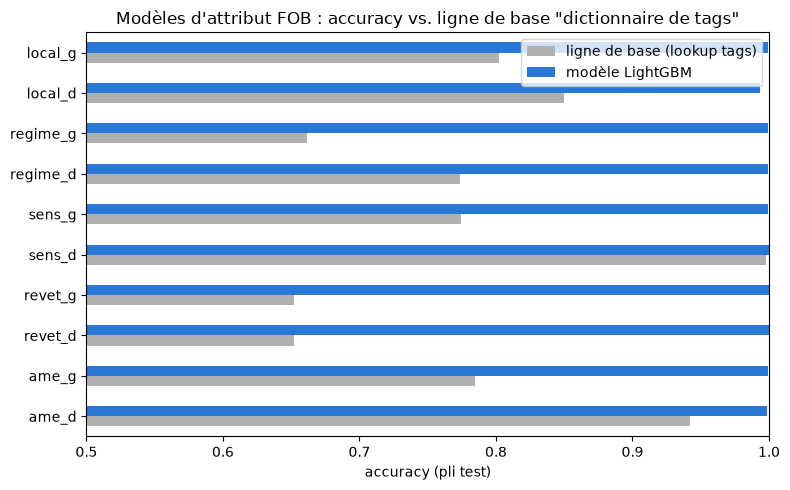

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
qualite_attributs[["baseline lookup (tags)", "accuracy"]].plot.barh(ax=ax, color=["#b0b0b0", "#2a78d6"])
ax.set_xlabel("accuracy (pli test)")
ax.set_title("Modèles d'attribut FOB : accuracy vs. ligne de base \"dictionnaire de tags\"")
ax.set_xlim(0.5, 1.0)
ax.legend(["ligne de base (lookup tags)", "modèle LightGBM"])
fig.tight_layout()
plt.show()

## 1. Résultat déjà préparé (ou à préparer) — [`pipeline.py`](pipeline.py)

Ce notebook réutilise directement la sortie de `pipeline.py` pour l'année `ANNEE` si elle existe déjà
(voir son README - la passe A à elle seule lit l'intégralité de l'extrait OSM France, plusieurs
dizaines de minutes) ; sinon, l'appelle.

In [6]:
dossier_annee = DOSSIER_SORTIE / str(ANNEE)
if not (dossier_annee / "ways.parquet").exists():
    print("Pas encore calculé - lancement de pipeline.py (peut prendre du temps, voir le README).")
    import runpy
    runpy.run_path(str(ICI / "pipeline.py"), run_name="__main__")
else:
    print(f"Déjà calculé : {dossier_annee}")

Déjà calculé : C:\Users\olivi\Documents\GitHub\LEVEL-Cyclist-Risk-Estimation\VV6\data\donnees_valides\reseau_fob\2024


## 2. Les tronçons retenus — [`ways.parquet`](schemas_fob.py)

Une ligne par tronçon FOB, avec ses 10 attributs prédits (voir `etiquettes.CIBLES`) et leur confiance.

In [7]:
ways = pd.read_parquet(dossier_annee / "ways.parquet")
print(f"{len(ways):,} tronçons FOB en {ANNEE}")
ways[["id_osm", "highway", "p_incl", "pred_ame_d", "pred_ame_g", "pred_sens_d", "length_m"]].head(10)

384,679 tronçons FOB en 2024


,id_osm,highway,p_incl,pred_ame_d,pred_ame_g,pred_sens_d,length_m
0,2574,tertiary,0.998922,AUCUN,COULOIR BUS+VELO,UNIDIRECTIONNEL,245.357445
1,85073,tertiary,0.999743,BANDE CYCLABLE,AUCUN,UNIDIRECTIONNEL,67.727409
2,85074,tertiary,0.999722,BANDE CYCLABLE,AUCUN,UNIDIRECTIONNEL,12.865362
3,85076,tertiary,0.998365,BANDE CYCLABLE,BANDE CYCLABLE,UNIDIRECTIONNEL,36.831121
4,101549,secondary,0.999682,COULOIR BUS+VELO,AUCUN,UNIDIRECTIONNEL,151.349701
5,101568,residential,0.994511,AUCUN,COULOIR BUS+VELO,UNIDIRECTIONNEL,55.218257
6,101575,residential,0.999940,AUTRE,DOUBLE SENS CYCLABLE BANDE,UNIDIRECTIONNEL,181.724128
7,101576,residential,0.996282,AUCUN,DOUBLE SENS CYCLABLE NON MATERIALISE,UNIDIRECTIONNEL,160.838029
8,101586,residential,0.999612,BANDE CYCLABLE,BANDE CYCLABLE,UNIDIRECTIONNEL,325.468339
9,101589,unclassified,0.997849,BANDE CYCLABLE,BANDE CYCLABLE,UNIDIRECTIONNEL,390.068055


## 3. Longueur par commune — [`longueurs.py`](longueurs.py)

Deux tables : FOB (tout le réseau retenu) et FOB_AM (restreint aux aménagements DÉDIÉS - voir
`etiquettes.est_amenagement`). C'est FOB_AM qui compte pour une analyse par type d'aménagement (section
suivante).

In [8]:
longueurs_fob = pd.read_parquet(dossier_annee / "longueurs_fob.parquet")
longueurs_fob_am = pd.read_parquet(dossier_annee / "longueurs_fob_amenagements.parquet")

km_fob = longueurs_fob["len_d"].sum() + longueurs_fob["len_g"].sum()
km_fob_am = longueurs_fob_am["len_d"].sum() + longueurs_fob_am["len_g"].sum()
print(f"FOB (tout)        : {km_fob:,.0f} km effectifs, {len(longueurs_fob):,} communes")
print(f"FOB_AM (aménagé)  : {km_fob_am:,.0f} km effectifs, {len(longueurs_fob_am):,} communes")
print(f"Part aménagée     : {km_fob_am / km_fob:.1%}")

FOB (tout)        : 137,961 km effectifs, 13,723 communes
FOB_AM (aménagé)  : 116,876 km effectifs, 11,128 communes
Part aménagée     : 84.7%


## 4. Analyse des aménagements — [`etiquettes.py`](etiquettes.py)

Le réseau FOB "tout" mélange des vrais aménagements dédiés (piste cyclable, voie verte...) et des
tronçons simplement jugés cyclables SANS aménagement particulier (une rue résidentielle calme, par
exemple - voir `etiquettes.TYPES_NON_AMENAGES`). Cette section décompose UNIQUEMENT la partie
aménagement dédié (FOB_AM, voir `etiquettes.est_amenagement`) par famille lisible
(`etiquettes.FAMILLE` regroupe les 12 catégories d'aménagement dédié de `HIERARCHIE` - AUTRE/AUCUN/NON_
RENSEIGNE n'y ont volontairement PAS d'entrée : ce ne sont pas des types d'aménagement, les compter
comme une "famille" mélangerait de vraies infrastructures avec des rues qui n'en ont aucune).

**FOB vs FOB_AM : ni l'un ni l'autre n'est "le meilleur" jeu de données dans l'absolu** - FOB (tout)
capture le linéaire réellement roulable à vélo (y compris en circulation mixte), pertinent pour une
exposition/un linéaire parcouru ; FOB_AM ne garde que ce qui a une infrastructure DÉDIÉE, pertinent
seulement pour étudier cette infrastructure elle-même (ce que fait cette section). Le choix entre les
deux dépend de l'usage des étapes suivantes du projet - voir `longueurs.py`.

In [9]:
import etiquettes as L

ways_inclus = ways[ways["incl"]].copy()
ways_inclus["type_principal"] = L.type_principal(ways_inclus["pred_ame_d"], ways_inclus["pred_ame_g"])
ways_inclus["km"] = ways_inclus["length_m"].fillna(0) / 1000
ways_inclus["amenagement"] = L.est_amenagement(ways_inclus["type_principal"])

km_total = ways_inclus["km"].sum()
km_non_amenage = ways_inclus.loc[~ways_inclus["amenagement"], "km"].sum()
print(f"Réseau FOB {ANNEE} total : {km_total:,.0f} km de réseau OSM (longueur brute)")
print(f"  dont SANS aménagement dédié (AUTRE/AUCUN/NON_RENSEIGNE) : {km_non_amenage:,.0f} km ({km_non_amenage / km_total:.1%}) - PAS une famille, exclu du détail ci-dessous")
print(f"  dont AVEC aménagement dédié (FOB_AM, détaillé par famille ci-dessous) : {km_total - km_non_amenage:,.0f} km ({1 - km_non_amenage / km_total:.1%})")

ways_amenages = ways_inclus[ways_inclus["amenagement"]].copy()
ways_amenages["famille"] = ways_amenages["type_principal"].map(L.FAMILLE)
assert ways_amenages["famille"].notna().all(), "un type d'aménagement dédié sans famille - etiquettes.FAMILLE est incomplet"

par_famille = ways_amenages.groupby("famille").agg(n_troncons=("id_osm", "size"), km_reseau_osm=("km", "sum")).sort_values("km_reseau_osm", ascending=False)
par_famille["part_de_FOB_AM"] = (par_famille["km_reseau_osm"] / par_famille["km_reseau_osm"].sum()).map("{:.1%}".format)
par_famille

Réseau FOB 2024 total : 69,355 km de réseau OSM (longueur brute)
  dont SANS aménagement dédié (AUTRE/AUCUN/NON_RENSEIGNE) : 10,741 km (15.5%) - PAS une famille, exclu du détail ci-dessous
  dont AVEC aménagement dédié (FOB_AM, détaillé par famille ci-dessous) : 58,613 km (84.5%)


,n_troncons,km_reseau_osm,part_de_FOB_AM
famille,,,
Piste cyclable,105126,20142.090580,34.4%
Voie verte,72538,15452.983129,26.4%
Bande cyclable,74575,9810.407033,16.7%
Double sens cyclable / vélo-rue,53208,6911.016941,11.8%
Autre aménagement de chaussée,18083,3350.646545,5.7%
Aménagement mixte piéton-vélo,23530,2945.915413,5.0%


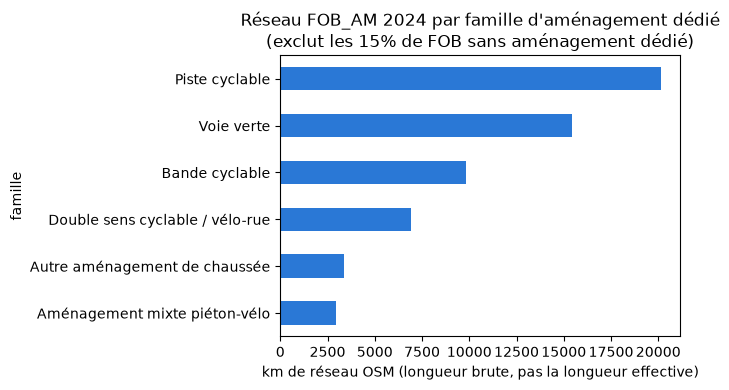

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
par_famille["km_reseau_osm"].sort_values().plot.barh(ax=ax, color="#2a78d6")
ax.set_xlabel("km de réseau OSM (longueur brute, pas la longueur effective)")
ax.set_title(f"Réseau FOB_AM {ANNEE} par famille d'aménagement dédié\n(exclut les {km_non_amenage / km_total:.0%} de FOB sans aménagement dédié)")
fig.tight_layout()
plt.show()

## 5. Tronçons à cheval sur plusieurs communes — [`decoupe_communes.py`](decoupe_communes.py)

Un tronçon qui traverse une frontière communale est RÉPARTI entre les communes concernées, au prorata
de la longueur qui tombe dans chacune (voir `decoupe_communes.decouper_troncons`) - pas attribué en
bloc à une seule commune. Un tronçon dont la géométrie n'a pas pu être localisée (repli) est
exceptionnellement attribué en bloc à la commune de son point médian - un cas rare, voir les chiffres
ci-dessous.

In [11]:
meta = __import__("json").loads((dossier_annee / "meta.json").read_text(encoding="utf-8"))
print(f"Tronçons à cheval sur >= 2 communes (répartis au prorata) : {meta['n_troncons_multi_communes']:,} / {meta['n_troncons']:,}")
print(f"Tronçons en repli (géométrie non localisée, attribués en bloc à la commune de leur point médian) : {meta['n_troncons_repli_point_median']:,}")
print(f"km OSM total : {meta['km_osm']:,.0f} ; km dans le périmètre métropole hors Corse : {meta['km_perimetre']:,.0f}")

Tronçons à cheval sur >= 2 communes (répartis au prorata) : 18,088 / 394,283
Tronçons en repli (géométrie non localisée, attribués en bloc à la commune de leur point médian) : 0
km OSM total : 69,355 ; km dans le périmètre métropole hors Corse : 68,872


## 6. résulé

**Méthode.** FOB apprend, par LightGBM, à reconnaître le codage GéoVélo à partir des seuls tags
OpenStreetMap (voir section 0.1 / `entrainement.py`) - un modèle d'inclusion, puis 10 modèles
d'attribut, découpage entraînement/validation/test déterministe par id OSM. Les modèles utilisés ici
sont ceux déjà entraînés et vendorisés (`models/fob/`, section 0.2/0.3) - ce notebook ne réentraîne
jamais rien.

**Qualité du modèle.** Inclusion : précision et rappel > 0.99 sur le pli test (voir 0.2) - très peu de
tronçons cyclables manqués ou ajoutés à tort. Attributs : accuracy > 0.99 pour la quasi-totalité des
cibles, et largement au-dessus de la ligne de base "dictionnaire de tags" (voir 0.3) - le modèle
apprend bien plus qu'une simple règle.

**Résultat réel (2024).** Voir sections 1 à 5 : 384 679 tronçons FOB retenus sur toute la France
(12,1 M de tronçons `highway=*` analysés), 137 961 km effectifs. Parmi eux, 116 876 km (84,7 %) ont
un aménagement cyclable DÉDIÉ (FOB_AM, détaillé par famille en section 4 - piste cyclable et voie verte
en tête) ; les 15,3 % restants sont des tronçons jugés cyclables SANS aménagement particulier (rue
calme, par exemple) - ni l'un ni l'autre n'est "le" jeu de données à utiliser dans l'absolu, le choix
FOB/FOB_AM dépend de l'usage (voir `longueurs.py`). 18 088 tronçons à cheval sur plusieurs communes
correctement répartis au prorata par découpe géométrique (section 5), 0 repli nécessaire vers la
commune du point médian (100 % des tronçons localisés).
